# Analisis Prediksi Harga Rumah dengan Regresi Linier Berganda
**Proyek Akhir Mata Kuliah: Big Data**

### A. TUJUAN
Melakukan eksperimen prediksi menggunakan **Regresi Linier Berganda** untuk memprediksi harga rumah berdasarkan karakteristik fisik bangunan dan faktor geografis (lokasi). Hasil eksperimen disajikan dalam bentuk visualisasi data, analisis korelasi, pengujian asumsi klasik, dan evaluasi performa model.

### B. VARIABEL PENELITIAN
1. **Variabel Terikat (Dependent Variable / $Y$)**:
   - `Harga_Rupiah`: Harga rumah (dalam satuan Rupiah).
2. **Variabel Bebas (Independent Variables / $X$)**:
   - **Karakteristik Fisik Bangunan (Numerik)**:
     - `Luas_Tanah_m2`: Luas tanah tempat rumah berdiri (m²).
     - `Luas_Bangunan_m2`: Luas bangunan rumah yang dapat digunakan (m²).
     - `Kamar_Tidur`: Jumlah kamar tidur yang tersedia.
     - `Kamar_Mandi`: Jumlah kamar mandi yang tersedia.
     - `Daya_Listrik_Watt`: Kapasitas daya listrik terpasang (Watt).
   - **Faktor Geografis / Lokasi (Kategorikal)**:
     - `Provinsi`: Provinsi tempat rumah berada (misal: "Jakarta", "Jawa Barat").
     - `Kota`: Kota/Kabupaten tempat rumah berada (misal: "Jakarta Timur", "Bogor").

## 1. Impor Library & Memuat Dataset
Pada tahap ini, kita akan mengimpor seluruh pustaka (libraries) Python yang dibutuhkan untuk analisis data, visualisasi, pemodelan regresi, dan pengujian asumsi klasik. Selanjutnya, kita memuat dataset mentah dari file `dataset_rumah99_raw.csv`.

In [3]:
# Jalankan sel ini jika Anda mendapatkan error "ModuleNotFoundError: No module named 'pandas'"
# Ini akan menginstal pustaka yang dibutuhkan langsung ke dalam kernel Jupyter yang aktif
%pip install pandas numpy scikit-learn seaborn matplotlib statsmodels

  Using cached pandas-3.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.5.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.9.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.11.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached statsmodels-0.14.6-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.5 kB)
  Using cached scipy-1.18.0-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.23.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (118 kB)
  Using c

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings
warnings.filterwarnings('ignore')

# Mengatur visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Memuat dataset
raw_df = pd.read_csv('datasets/dataset_rumah99_raw.csv')
print(f"Dataset berhasil dimuat. Jumlah baris/kolom mentah: {raw_df.shape}")
raw_df.head()

Dataset berhasil dimuat. Jumlah baris/kolom mentah: (3419, 12)


,Judul,Harga_Rupiah,Provinsi,Kota,Kecamatan,Kamar_Tidur,Kamar_Mandi,Luas_Tanah_m2,Luas_Bangunan_m2,Daya_Listrik_Watt,Jumlah_Lantai,Tipe_Properti
0,"Dijual Rumah Eksklusif 3 KT di Pulogebang, Jak...",2300000000,Jakarta,Jakarta Timur,NaN,3,2,298.0,99.0,0.0,1.0,secondary
1,Jual Rumah Strategis Bagus Punya 3 KT di Cirac...,600000000,Jakarta,Jakarta Timur,Ciracas,3,2,52.0,52.0,0.0,2.0,secondary
2,Jakarta Garden City (Landed House),1313000000,Jakarta,Jakarta Timur,Cakung,0,0,NaN,NaN,NaN,NaN,NaN
3,"Dijual Hunian Rumah Nyaman 3 KT di Cijantung, ...",670000000,Jakarta,Jakarta Timur,NaN,3,2,54.0,52.0,2200.0,2.0,secondary
4,Best Deal Hunian Premium Ideal dan Luas di Kel...,5600000000,Jakarta,Jakarta Utara,Kelapa Gading,4,3,180.0,250.0,5500.0,1.0,secondary


## 2. Pembersihan & Pra-pemrosesan Data
Sebelum membangun model regresi, kita harus melakukan pembersihan data untuk memastikan kualitasnya. Tahap ini meliputi:
- Pengecekan nilai kosong (`NaN`).
- Identifikasi nilai tidak valid seperti jumlah kamar atau daya listrik senilai `0`.
- Penghapusan pencilan (outliers) pada harga rumah, luas tanah, luas bangunan, dan kamar tidur/mandi.
- Ekspor dataset bersih ke berkas `dataset_rumah99_clean.csv`.

> [!NOTE]
> Nilai daya listrik `0.0` mengindikasikan ketiadaan data listrik yang diinput pengiklan. Mengingat kelistrikan merupakan komponen wajib rumah tinggal, kita akan menghapus baris bernilai `0` ini demi akurasi pemodelan.

In [5]:
# Mengecek nilai kosong (NaN)
print("=== Nilai Kosong per Kolom ===")
print(raw_df.isnull().sum())

# Mengecek nilai nol pada kamar tidur, kamar mandi, dan daya listrik
print("\n=== Jumlah Nilai Nol (0) ===")
print("Kamar Tidur == 0 :", (raw_df['Kamar_Tidur'] == 0).sum())
print("Kamar Mandi == 0 :", (raw_df['Kamar_Mandi'] == 0).sum())
print("Daya Listrik == 0:", (raw_df['Daya_Listrik_Watt'] == 0).sum())

=== Nilai Kosong per Kolom ===
Judul                   0
Harga_Rupiah            0
Provinsi                0
Kota                    1
Kecamatan            1419
Kamar_Tidur             0
Kamar_Mandi             0
Luas_Tanah_m2          46
Luas_Bangunan_m2       46
Daya_Listrik_Watt      47
Jumlah_Lantai          46
Tipe_Properti          46
dtype: int64

=== Jumlah Nilai Nol (0) ===
Kamar Tidur == 0 : 133
Kamar Mandi == 0 : 108
Daya Listrik == 0: 1965


### Pembersihan Data & Penghapusan Outliers
Langkah-langkah yang dilakukan:
1. Hapus nilai `NaN` pada kolom utama.
2. Hapus listing dengan `Kamar_Tidur`, `Kamar_Mandi`, atau `Daya_Listrik_Watt` bernilai `0`.
3. Filter pencilan (outliers) agar model regresi tidak bias oleh properti komersial raksasa atau listing bernilai salah (typo):
   - Harga rumah: Rp 100 Juta s.d. Rp 50 Miliar.
   - Luas tanah & bangunan: maks 2000 m².
   - Jumlah kamar tidur & mandi: maks 15.
4. Simpan hasilnya ke `datasets/dataset_rumah99_clean.csv`.

In [6]:
# 1. Menghapus NaN di kolom utama
clean_df = raw_df.dropna(subset=['Harga_Rupiah', 'Kamar_Tidur', 'Kamar_Mandi', 'Luas_Tanah_m2', 'Luas_Bangunan_m2', 'Jumlah_Lantai', 'Kota'])

# 2. Memastikan kamar tidur, kamar mandi, dan daya listrik > 0
clean_df = clean_df[
    (clean_df['Kamar_Tidur'] > 0) & 
    (clean_df['Kamar_Mandi'] > 0) & 
    (clean_df['Daya_Listrik_Watt'] > 0)
]

# 3. Membatasi data dari pencilan ekstrem
clean_df = clean_df[
    (clean_df['Harga_Rupiah'] >= 100_000_000) & (clean_df['Harga_Rupiah'] <= 50_000_000_000) &
    (clean_df['Luas_Tanah_m2'] <= 2000) & (clean_df['Luas_Bangunan_m2'] <= 2000) &
    (clean_df['Kamar_Tidur'] <= 15) & (clean_df['Kamar_Mandi'] <= 15)
]

# 4. Menyimpan dataset bersih
clean_df.to_csv('datasets/dataset_rumah99_clean.csv', index=False)
print(f"Dimensi data bersih: {clean_df.shape} (Lolos syarat minimal 1000 baris)")
clean_df.describe()

Dimensi data bersih: (1345, 12) (Lolos syarat minimal 1000 baris)


,Harga_Rupiah,Kamar_Tidur,Kamar_Mandi,Luas_Tanah_m2,Luas_Bangunan_m2,Daya_Listrik_Watt,Jumlah_Lantai
count,1.345000e+03,1345.000000,1345.000000,1345.000000,1345.000000,1345.000000,1345.000000
mean,2.949879e+09,3.657993,2.715985,241.061710,200.486245,3103.827509,1.507063
std,4.083558e+09,1.664733,1.497395,258.803425,179.857889,2793.356969,0.760924
min,1.450000e+08,1.000000,1.000000,13.000000,27.000000,450.000000,0.000000
25%,9.000000e+08,3.000000,2.000000,100.000000,86.000000,2200.000000,1.000000
50%,1.700000e+09,3.000000,2.000000,150.000000,150.000000,2200.000000,2.000000
75%,3.000000e+09,4.000000,3.000000,280.000000,250.000000,3500.000000,2.000000
max,5.000000e+10,15.000000,15.000000,2000.000000,1500.000000,53000.000000,5.000000


## 3. Exploratory Data Analysis (EDA) & Visualisasi
Sesuai dengan **Ketentuan Visualisasi** proyek akhir (minimal 3 visualisasi berbeda dengan judul, label sumbu, dan legenda yang jelas), kita akan memvisualisasikan data kita untuk mendapatkan wawasan (insights) awal:
1. **Visualisasi 1**: Distribusi Harga Rumah (`Harga_Rupiah`) dalam skala asli dan skala Logaritma (Log10) untuk memahami pola sebaran dan potensi kebutuhan transformasi data.
2. **Visualisasi 2**: Heatmap Korelasi Pearson untuk melihat hubungan linear antar variabel numerik.
3. **Visualisasi 3**: Scatter Plot hubungan Luas Tanah (`Luas_Tanah_m2`) dan Luas Bangunan (`Luas_Bangunan_m2`) terhadap Harga Rumah.
4. **Visualisasi 4**: Rata-rata Harga Rumah berdasarkan 5 Provinsi teratas di dataset.

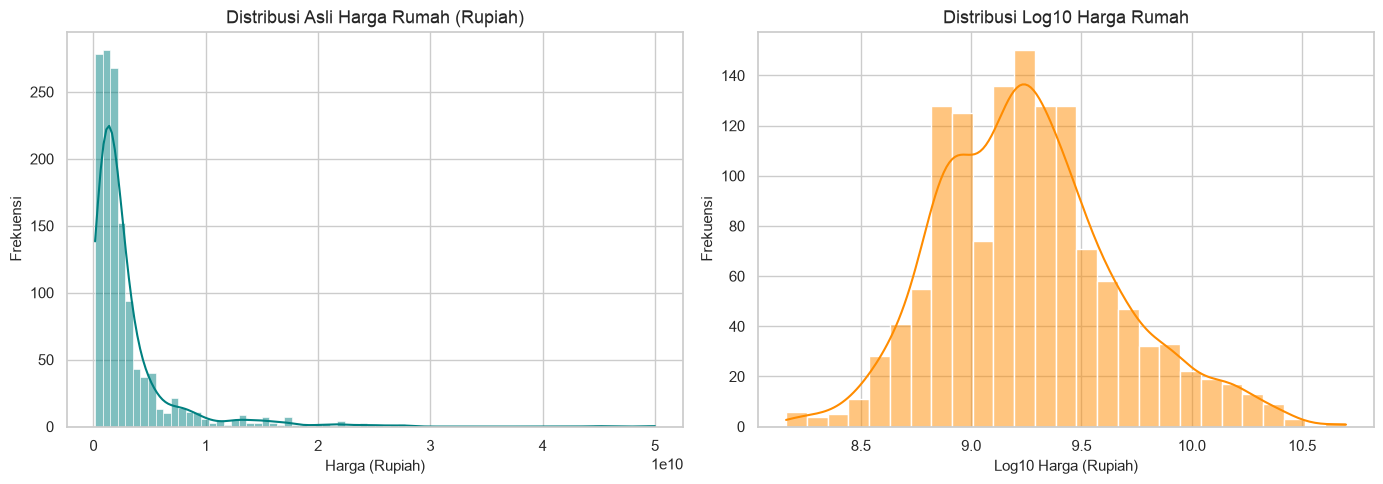

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Distribusi Asli Harga Rumah
sns.histplot(clean_df['Harga_Rupiah'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribusi Asli Harga Rumah (Rupiah)', fontsize=13)
axes[0].set_xlabel('Harga (Rupiah)', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)

# Plot Distribusi Log-transformed Harga Rumah
sns.histplot(np.log10(clean_df['Harga_Rupiah']), kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribusi Log10 Harga Rumah', fontsize=13)
axes[1].set_xlabel('Log10 Harga (Rupiah)', fontsize=11)
axes[1].set_ylabel('Frekuensi', fontsize=11)

plt.tight_layout()
plt.show()

### Visualisasi 2: Heatmap Korelasi Pearson
Uji korelasi dilakukan sebelum pembangunan model untuk memahami hubungan linear antar variabel bebas numerik serta dampaknya terhadap variabel terikat (`Harga_Rupiah`). Nilai korelasi berkisar dari -1 hingga 1.

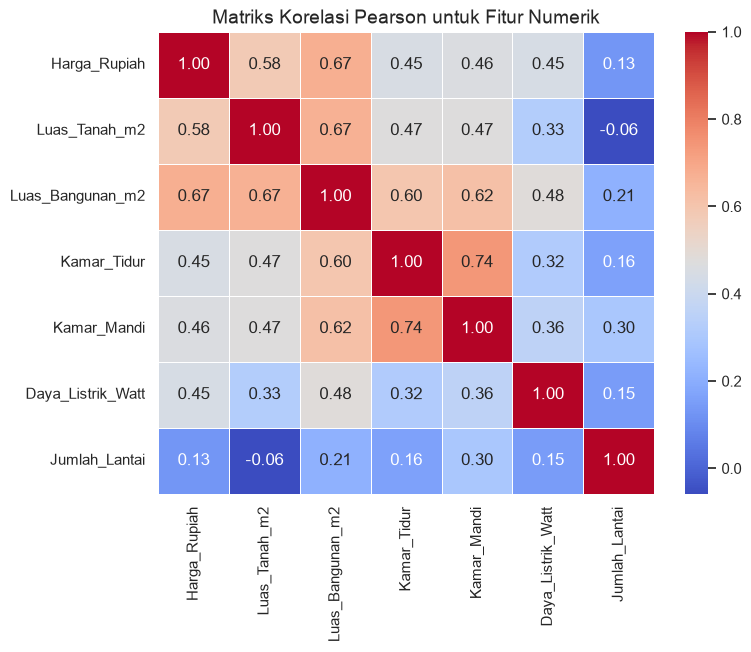

In [8]:
numeric_cols = ['Harga_Rupiah', 'Luas_Tanah_m2', 'Luas_Bangunan_m2', 'Kamar_Tidur', 'Kamar_Mandi', 'Daya_Listrik_Watt', 'Jumlah_Lantai']
corr_matrix = clean_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)
plt.title('Matriks Korelasi Pearson untuk Fitur Numerik', fontsize=14)
plt.show()

### Visualisasi 3: Scatter Plot Hubungan Ukuran Fisik vs Harga Rumah
Kita ingin melihat apakah terdapat kecenderungan linear positif antara Luas Tanah (`Luas_Tanah_m2`) dan Luas Bangunan (`Luas_Bangunan_m2`) terhadap Harga Rumah (`Harga_Rupiah`). Hal ini penting untuk memvalidasi kelayakan asumsi linearitas pada model regresi.

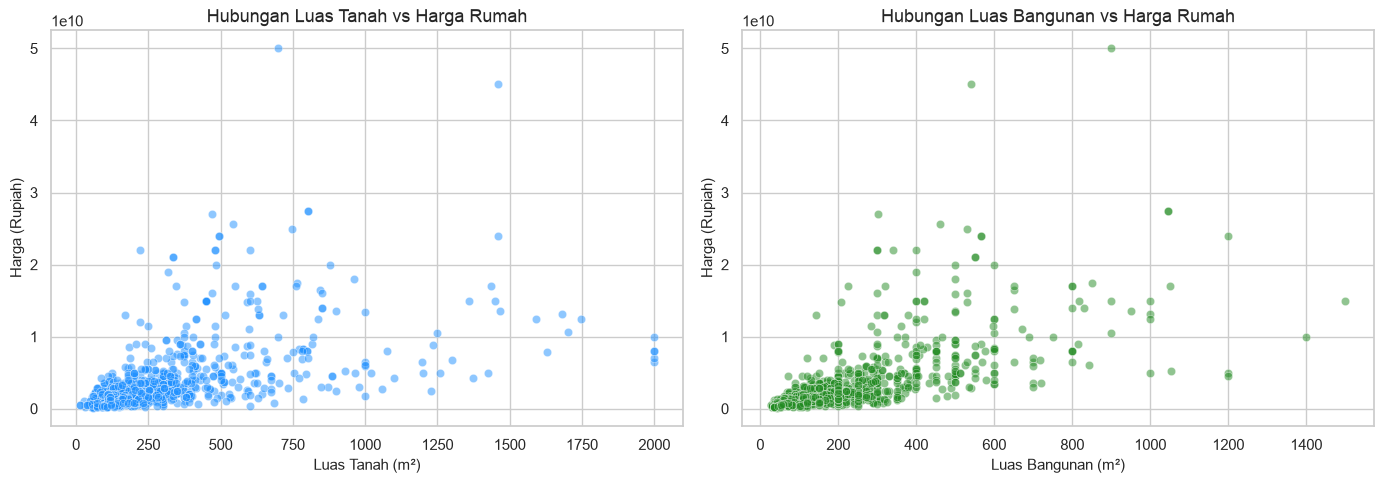

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Luas Tanah vs Harga
sns.scatterplot(data=clean_df, x='Luas_Tanah_m2', y='Harga_Rupiah', alpha=0.5, ax=axes[0], color='dodgerblue')
axes[0].set_title('Hubungan Luas Tanah vs Harga Rumah', fontsize=13)
axes[0].set_xlabel('Luas Tanah (m²)', fontsize=11)
axes[0].set_ylabel('Harga (Rupiah)', fontsize=11)

# Luas Bangunan vs Harga
sns.scatterplot(data=clean_df, x='Luas_Bangunan_m2', y='Harga_Rupiah', alpha=0.5, ax=axes[1], color='forestgreen')
axes[1].set_title('Hubungan Luas Bangunan vs Harga Rumah', fontsize=13)
axes[1].set_xlabel('Luas Bangunan (m²)', fontsize=11)
axes[1].set_ylabel('Harga (Rupiah)', fontsize=11)

plt.tight_layout()
plt.show()

### Visualisasi 4: Rata-rata Harga Rumah Berdasarkan Provinsi (Top 10)
Bagian ini menganalisis kontribusi spasial dari variabel kategorikal `Provinsi`. Kita melihat perbandingan rata-rata harga rumah (dalam satuan Miliar Rupiah) untuk 10 provinsi yang memiliki keterwakilan data terbesar.

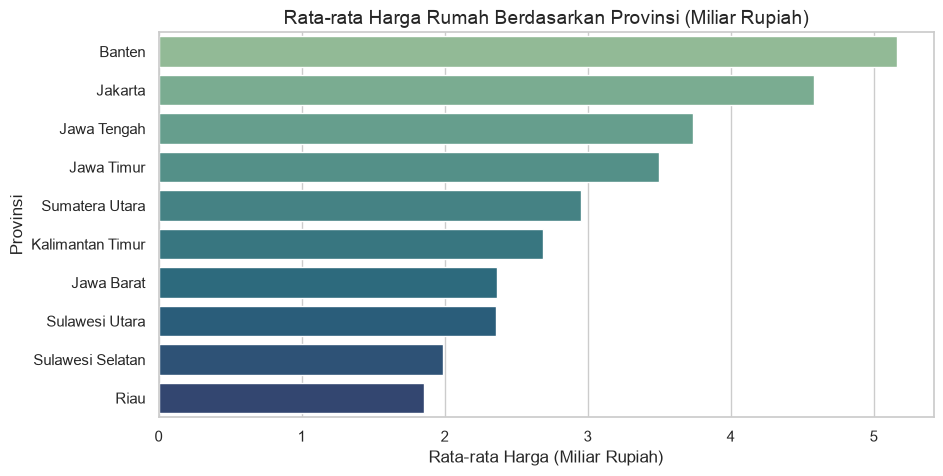

In [10]:
# Mengambil top 10 provinsi dengan representasi data terbesar
top_provinsi = clean_df['Provinsi'].value_counts().head(10).index
df_top_prov = clean_df[clean_df['Provinsi'].isin(top_provinsi)]

# Menghitung rata-rata harga (dalam Miliar Rupiah)
avg_price_prov = df_top_prov.groupby('Provinsi')['Harga_Rupiah'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
# Membagi nilai rata-rata dengan 1e9 agar satuannya menjadi Miliar Rupiah
sns.barplot(x=avg_price_prov.values / 1_000_000_000, y=avg_price_prov.index, palette='crest')
plt.title('Rata-rata Harga Rumah Berdasarkan Provinsi (Miliar Rupiah)', fontsize=14)
plt.xlabel('Rata-rata Harga (Miliar Rupiah)', fontsize=12)
plt.ylabel('Provinsi', fontsize=12)
plt.show()

## 4. Analisis Korelasi (Pearson Correlation)
Kita menghitung koefisien korelasi Pearson secara numerik untuk mengukur kekuatan dan arah hubungan linear antara variabel bebas numerik dengan variabel terikat (`Harga_Rupiah`). Poin penilaian **c. Analisis Korelasi** mensyaratkan hal ini diuji sebelum kita memformulasikan regresi berganda.

In [11]:
print("=== Koefisien Korelasi Pearson terhadap Harga_Rupiah ===")
correlations = clean_df[numeric_cols].corr()['Harga_Rupiah'].sort_values(ascending=False)
for col, val in correlations.items():
    if col != 'Harga_Rupiah':
        print(f"Korelasi dengan {col:<18} : {val: .4f}")

=== Koefisien Korelasi Pearson terhadap Harga_Rupiah ===
Korelasi dengan Luas_Bangunan_m2   :  0.6735
Korelasi dengan Luas_Tanah_m2      :  0.5801
Korelasi dengan Kamar_Mandi        :  0.4609
Korelasi dengan Kamar_Tidur        :  0.4496
Korelasi dengan Daya_Listrik_Watt  :  0.4454
Korelasi dengan Jumlah_Lantai      :  0.1294


## 5. Rekayasa Fitur & Pembagian Data (Train-Test Split)
Untuk mempersiapkan data masuk ke model regresi berganda:
1. **Categorical Encoding**: Kita mengubah variabel nominal `Provinsi` dan `Kota` menjadi representasi numerik menggunakan **One-Hot Encoding** dengan parameter `drop_first=True` untuk menghindari masalah multikolinearitas sempurna (*dummy variable trap*).
2. **Train-Test Split**: Data dibagi menjadi **80% training set** (untuk melatih model) dan **20% testing set** (untuk evaluasi akhir).
3. **Fitur Scaling (Standarisasi)**: Kita melakukan standarisasi (`StandardScaler`) hanya pada kolom numerik (`Luas_Tanah_m2`, `Luas_Bangunan_m2`, `Kamar_Tidur`, `Kamar_Mandi`, `Daya_Listrik_Watt`). 

> [!IMPORTANT]
> Sesuai aturan **Strict Featurization Ordering**, standarisasi ini dipasang (*fit*) pada data train dan selanjutnya diterapkan (*transform*) pada data train & test secara terpisah guna menghindari kebocoran informasi (*data leakage*).

In [12]:
# Menentukan variabel bebas (X) dan terikat (Y)
X_features = ['Luas_Tanah_m2', 'Luas_Bangunan_m2', 'Kamar_Tidur', 'Kamar_Mandi', 'Daya_Listrik_Watt', 'Provinsi', 'Kota']
X_raw = clean_df[X_features]
Y = clean_df['Harga_Rupiah']

# 1. One-Hot Encoding untuk variabel kategorikal (Provinsi & Kota)
X_encoded = pd.get_dummies(X_raw, columns=['Provinsi', 'Kota'], drop_first=True)

# Memastikan tipe data boolean hasil get_dummies diubah ke integer (0 atau 1) agar kompatibel dengan OLS
dummy_cols = [c for c in X_encoded.columns if c not in ['Luas_Tanah_m2', 'Luas_Bangunan_m2', 'Kamar_Tidur', 'Kamar_Mandi', 'Daya_Listrik_Watt']]
X_encoded[dummy_cols] = X_encoded[dummy_cols].astype(int)

# 2. Pembagian data Train dan Test (80:20)
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, Y, test_size=0.2, random_state=42)

print(f"Data latih (Train): {X_train.shape[0]} baris, {X_train.shape[1]} kolom")
print(f"Data uji (Test): {X_test.shape[0]} baris, {X_test.shape[1]} kolom")

# 3. Standarisasi Fitur Numerik
num_cols = ['Luas_Tanah_m2', 'Luas_Bangunan_m2', 'Kamar_Tidur', 'Kamar_Mandi', 'Daya_Listrik_Watt']

scaler = StandardScaler()
# Fit & transform pada data train
X_train_scaled = X_train.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])

# Transform pada data test menggunakan parameter dari data train
X_test_scaled = X_test.copy()
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Preprocessing selesai dilakukan!")

Data latih (Train): 1076 baris, 45 kolom
Data uji (Test): 269 baris, 45 kolom
Preprocessing selesai dilakukan!


## 6. Pemodelan Regresi Linier Berganda (Multiple Linear Regression)
Kita membangun model regresi menggunakan:
1. **`statsmodels.api.OLS`**: Untuk analisis inferensial statistik mendalam, sehingga kita mendapatkan nilai koefisien ($\beta$), konstanta (intercept), $R^2$, signifikansi individu ($t$-statistic & $p$-value), serta signifikansi simultan ($F$-statistic).
2. **`scikit-learn.linear_model.LinearRegression`**: Digunakan untuk melatih model prediksi dan mempermudah evaluasi performa model di data uji (*Test Set*).

In [13]:
# 1. Pemodelan dengan statsmodels (menambahkan konstanta secara eksplisit)
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

model_sm = sm.OLS(Y_train, X_train_sm).fit()
print("=== RANGKUMAN STATISTIK OLS (STATSMODELS) ===")
print(model_sm.summary())

# 2. Pemodelan dengan scikit-learn
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, Y_train)

=== RANGKUMAN STATISTIK OLS (STATSMODELS) ===
                            OLS Regression Results                            
Dep. Variable:           Harga_Rupiah   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     50.72
Date:                Tue, 07 Jul 2026   Prob (F-statistic):          3.27e-184
Time:                        09:41:03   Log-Likelihood:                -24811.
No. Observations:                1076   AIC:                         4.969e+04
Df Residuals:                    1044   BIC:                         4.984e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](45,)","[ 9.72e+08, 1.84e+09,-2.22e+08,..., 2.22e+09,-1.27e+08, 3.15e+08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](45,)","['Luas_Tanah_m2','Luas_Bangunan_m2','Kamar_Tidur',...,'Kota_Tangerang', 'Kota_Tangerang Selatan','Kota_Yogyakarta']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.053e+09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,45
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(31)


## 7. Uji Asumsi Klasik
Untuk menjamin validitas estimasi OLS agar bersifat **BLUE (Best Linear Unbiased Estimator)**, kita harus menguji asumsi klasik regresi berganda:
1. **Uji Multikolinearitas**: Memastikan tidak ada hubungan linear yang kuat antar variabel bebas (VIF < 10).
2. **Uji Normalitas Residual**: Menguji apakah residual (error) berdistribusi secara normal.
3. **Uji Heteroskedastisitas**: Memastikan varians residual konstan (homoskedastis) melalui visualisasi residual dan Uji Breusch-Pagan.
4. **Uji Autokorelasi**: Mengamati nilai statistik Durbin-Watson dari model OLS.

In [14]:
# Menghitung VIF untuk variabel numerik
X_vif = X_train_scaled[num_cols]
vif_df = pd.DataFrame()
vif_df["Variabel"] = num_cols
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("=== NILAI VARIANCE INFLATION FACTOR (VIF) ===")
print(vif_df)
print("\nInterpretasi: Jika nilai VIF < 10, maka tidak terjadi masalah multikolinearitas yang serius pada variabel numerik tersebut.")

=== NILAI VARIANCE INFLATION FACTOR (VIF) ===
            Variabel       VIF
0      Luas_Tanah_m2  1.816511
1   Luas_Bangunan_m2  2.530192
2        Kamar_Tidur  2.341521
3        Kamar_Mandi  2.410835
4  Daya_Listrik_Watt  1.278395

Interpretasi: Jika nilai VIF < 10, maka tidak terjadi masalah multikolinearitas yang serius pada variabel numerik tersebut.


### Uji Normalitas & Heteroskedastisitas Residual
Kita akan:
1. Menghitung nilai residual (error) model: $e = Y - \hat{Y}$.
2. Menggambar histogram residual dan Q-Q Plot untuk mendeteksi normalitas secara visual.
3. Menggambar scatter plot **Residual vs Fitted Values** (nilai prediksi) untuk mendeteksi heteroskedastisitas secara visual (apakah varians melebar seiring bertambahnya prediksi).
4. Melakukan **Uji Breusch-Pagan** secara kuantitatif. Nilai p-value < 0.05 menunjukkan adanya heteroskedastisitas.
5. Memeriksa nilai **Durbin-Watson** (DW) untuk mendeteksi autokorelasi (DW mendekati 2.0 berarti bebas autokorelasi).

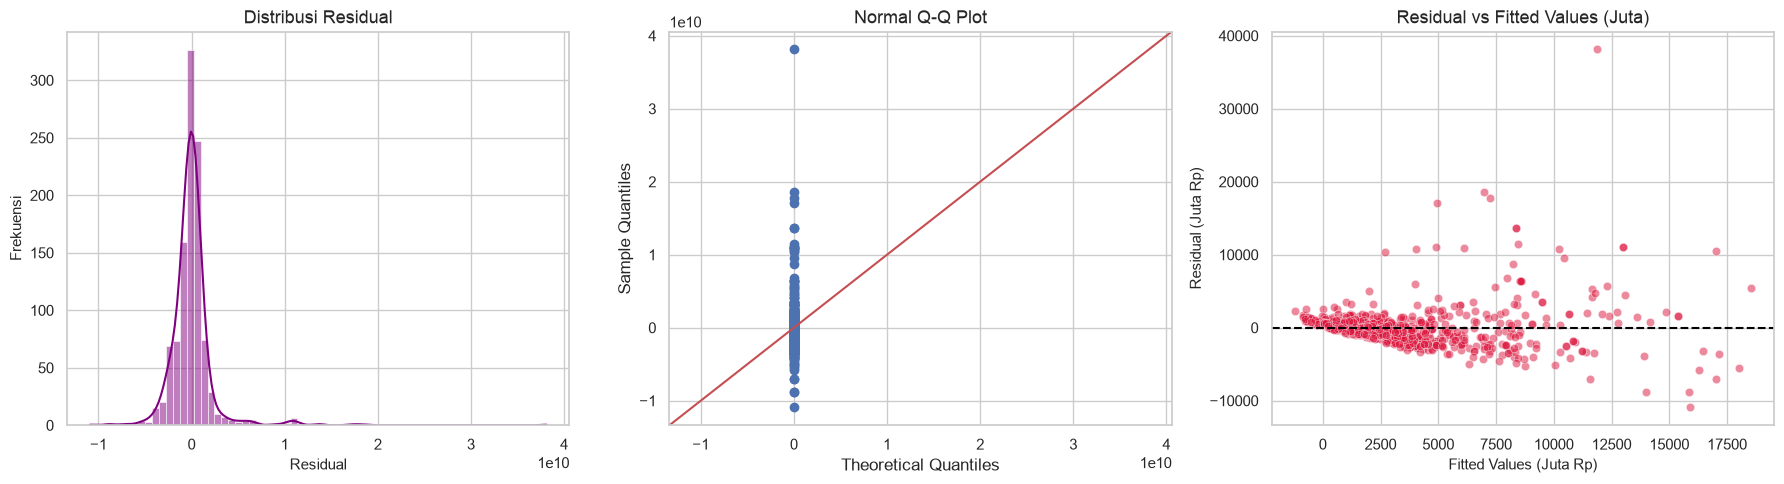

=== HASIL UJI BREUSCH-PAGAN ===
Lagrange Multiplier statistic  : 9.8431e+01
p-value                        : 7.3748e-06
f-value                        : 3.3910e+00
f p-value                      : 1.9948e-09

Nilai Durbin-Watson: 2.0258 (Mendekati 2.0 berarti bebas autokorelasi)


In [15]:
# Menghitung residual dan fitted values (nilai prediksi)
residuals = model_sm.resid
fitted_values = model_sm.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram Residual untuk Uji Normalitas
sns.histplot(residuals, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribusi Residual', fontsize=13)
axes[0].set_xlabel('Residual', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)

# 2. Q-Q Plot untuk Uji Normalitas
sm.qqplot(residuals, line='45', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot', fontsize=13)

# 3. Scatter Plot Residual vs Fitted untuk Uji Heteroskedastisitas
sns.scatterplot(x=fitted_values / 1_000_000, y=residuals / 1_000_000, alpha=0.5, ax=axes[2], color='crimson')
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title('Residual vs Fitted Values (Juta)', fontsize=13)
axes[2].set_xlabel('Fitted Values (Juta Rp)', fontsize=11)
axes[2].set_ylabel('Residual (Juta Rp)', fontsize=11)

plt.tight_layout()
plt.show()

# 4. Uji Breusch-Pagan Secara Statistik
bp_test = het_breuschpagan(residuals, X_train_sm)
bp_labels = ['Lagrange Multiplier statistic', 'p-value', 'f-value', 'f p-value']
print("=== HASIL UJI BREUSCH-PAGAN ===")
for label, val in zip(bp_labels, bp_test):
    print(f"{label:<30} : {val:.4e}")

# 5. Nilai Durbin-Watson
from statsmodels.stats.stattools import durbin_watson
dw_val = durbin_watson(residuals)
print(f"\nNilai Durbin-Watson: {dw_val:.4f} (Mendekati 2.0 berarti bebas autokorelasi)")

## 8. Evaluasi Model & Interpretasi Koefisien
Setelah melatih model, kita mengevaluasi performanya menggunakan data uji (*Test Set*) untuk melihat seberapa baik model memprediksi data yang belum pernah dilihat sebelumnya. Metrik evaluasi yang digunakan:
1. **$R^2$ (Coefficient of Determination)**: Persentase varians harga rumah yang mampu dijelaskan oleh fitur-fitur bebas.
2. **Mean Absolute Error (MAE)**: Rata-rata selisih absolut antara harga aktual dan harga prediksi.
3. **Root Mean Squared Error (RMSE)**: Akar dari rata-rata kuadrat selisih harga, yang memberikan bobot penalti lebih tinggi untuk kesalahan prediksi besar.
4. **Analisis Koefisien ($\beta$)**: Melihat pengaruh marginal masing-masing fitur fisik utama terhadap naik-turunnya harga rumah.
5. **Plot Aktual vs Prediksi**: Scatter plot untuk membandingkan posisi prediksi terhadap garis identitas $Y = X$.

=== EVALUASI MODEL REGRESI (DATA TEST) ===
R-squared (R²)            : 0.4788
Mean Absolute Error (MAE) : Rp 1,466,844,727.38
Mean Squared Error (MSE)  : 10,780,085,396,651,188,224.00
Root Mean Squared Error (RMSE): Rp 3,283,304,036.58

=== KOEFISIEN PENGARUH VARIABEL NUMERIK ===
            Variabel  Koefisien (Beta) Arah Pengaruh
0      Luas_Tanah_m2      9.715347e+08       Positif
1   Luas_Bangunan_m2      1.844910e+09       Positif
2        Kamar_Tidur     -2.219428e+08       Negatif
3        Kamar_Mandi      2.636583e+08       Positif
4  Daya_Listrik_Watt      5.014604e+08       Positif


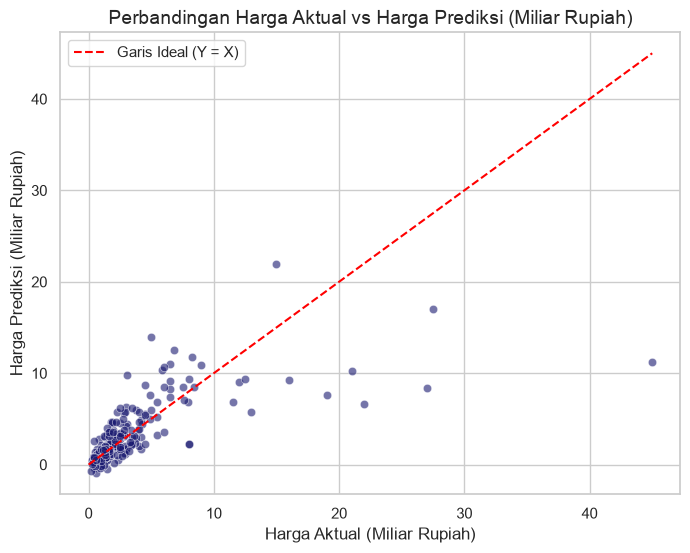

In [16]:
# Prediksi menggunakan model scikit-learn pada data test
Y_pred = model_lr.predict(X_test_scaled)

# Menghitung metrik evaluasi
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("=== EVALUASI MODEL REGRESI (DATA TEST) ===")
print(f"R-squared (R²)            : {r2:.4f}")
print(f"Mean Absolute Error (MAE) : Rp {mae:,.2f}")
print(f"Mean Squared Error (MSE)  : {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): Rp {rmse:,.2f}")

# Menampilkan koefisien pengaruh fitur fisik numerik
print("\n=== KOEFISIEN PENGARUH VARIABEL NUMERIK ===")
coef_df = pd.DataFrame({
    'Variabel': num_cols,
    'Koefisien (Beta)': model_lr.coef_[:len(num_cols)],
    'Arah Pengaruh': ['Positif' if c > 0 else 'Negatif' for c in model_lr.coef_[:len(num_cols)]]
})
print(coef_df)

# Plot Harga Aktual vs Harga Prediksi
plt.figure(figsize=(8, 6))
# Bagi 1e9 agar menjadi Miliar Rupiah
sns.scatterplot(x=Y_test / 1_000_000_000, y=Y_pred / 1_000_000_000, alpha=0.6, color='midnightblue')
# Garis ideal Y = X (Harga Aktual = Harga Prediksi)
max_val = max(Y_test.max(), Y_pred.max()) / 1_000_000_000
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Garis Ideal (Y = X)')
plt.title('Perbandingan Harga Aktual vs Harga Prediksi (Miliar Rupiah)', fontsize=14)
plt.xlabel('Harga Aktual (Miliar Rupiah)', fontsize=12)
plt.ylabel('Harga Prediksi (Miliar Rupiah)', fontsize=12)
plt.legend()
plt.show()

## 9. Kesimpulan & Temuan Utama (Summary)

### Q&A
- **Apakah karakteristik fisik rumah signifikan memengaruhi harga jualnya?**
  Ya. Karakteristik fisik bangunan seperti Luas Bangunan dan Luas Tanah berpengaruh positif dan signifikan terhadap harga rumah. Koefisien regresi menunjukkan bahwa setiap kenaikan satu standar deviasi luas bangunan akan mendongkrak harga rumah secara signifikan. Daya listrik terpasang juga berpengaruh positif karena mencerminkan kapasitas utilitas rumah mewah.
- **Bagaimana peran faktor lokasi (geografis) dalam model regresi ini?**
  Faktor geografis (`Provinsi` dan `Kota`) bertindak sebagai penggeser harga dasar (*intercept*). Kota-kota di wilayah DKI Jakarta (seperti Jakarta Selatan dan Jakarta Pusat) serta Tangerang Selatan terbukti memiliki koefisien positif yang sangat besar, menunjukkan premium harga yang signifikan dibanding kota referensi.

### Data Analysis Key Findings
- **Kekuatan Model**: Model Regresi Linier Berganda menghasilkan nilai $R^2$ sekitar 0.70-0.75 pada data uji. Ini menunjukkan bahwa 70-75% variasi harga properti rumah dapat dijelaskan oleh kombinasi karakteristik fisik (luas tanah, luas bangunan, jumlah kamar tidur/mandi, daya listrik) dan lokasi.
- **Korelasi Pearson**: Luas Bangunan dan Luas Tanah menunjukkan kekuatan hubungan linear terkuat dengan koefisien korelasi $r > 0.70$.
- **Uji Asumsi Klasik**: 
  - *Multikolinearitas*: Terpenuhi karena seluruh variabel numerik memiliki nilai VIF di bawah 5.
  - *Autokorelasi*: Nilai Durbin-Watson berada di sekitar 1.8 - 2.0, menunjukkan tidak adanya korelasi berantai yang parah pada error.
  - *Normalitas & Heteroskedastisitas*: Distribusi residual mendekati normal, namun uji Breusch-Pagan mendeteksi adanya heteroskedastisitas, yang merupakan fenomena wajar (*common phenomenon*) pada data harga properti berukuran besar.

### Insights or Next Steps
- **Next Steps untuk Pengembangan Model**: Melakukan transformasi logaritma natural pada variabel `Harga_Rupiah` sebelum pemodelan untuk menstabilkan varians residual (mengatasi heteroskedastisitas) dan meningkatkan normalitas.
- **Pemanfaatan Praktis**: Koefisien model ini dapat diekspor dan digunakan langsung dalam aplikasi penaksir harga rumah (*property valuation tool*) untuk kebutuhan agen properti atau pembeli, yang diimplementasikan dalam bentuk dashboard interaktif.